# Customer Churn Predictor — Analysis Notebook
**Data Science Final Project**  
Data source: OMDb API (simulated streaming users)

---


## 1. Setup & Data Loading

In [2]:
import sys, warnings
sys.path.append("../app")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from features import load_raw, build_movie_index, build_features, FEATURE_COLS

movies, users = load_raw()
movie_index = build_movie_index(movies)
df = build_features(users, movie_index)

print(f"Dataset: {df.shape[0]} users, {len(FEATURE_COLS)} features")
print(f"Churn rate: {df['churned'].mean():.1%}")
df.head()


Dataset: 300 users, 10 features
Churn rate: 37.7%


,user_id,avg_rating_given,rating_std,watch_rate_per_week,days_since_last_watch,genre_diversity,preferred_genre_ratio,avg_imdb_rating_watched,avg_runtime_watched,recent_watch_count,account_age_days,churned
0,user_0000,5.428571,0.979379,0.240196,131.0,9.0,0.000000,6.071429,91.857143,0.0,204.0,1
1,user_0001,6.117021,1.398224,0.599271,25.0,19.0,0.382979,6.334783,93.659574,2.0,549.0,0
2,user_0002,6.603333,1.221879,0.328638,24.0,18.0,0.666667,6.186207,94.241379,1.0,639.0,0
3,user_0003,5.480000,1.519737,0.216049,69.0,12.0,0.500000,6.300000,87.555556,0.0,324.0,1
4,user_0004,6.433333,1.070825,0.331579,247.0,10.0,0.444444,5.955556,109.666667,0.0,190.0,1


## 2. Exploratory Data Analysis

In [3]:
df[FEATURE_COLS + ["churned"]].describe().round(2)


,avg_rating_given,rating_std,watch_rate_per_week,days_since_last_watch,genre_diversity,preferred_genre_ratio,avg_imdb_rating_watched,avg_runtime_watched,recent_watch_count,account_age_days,churned
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,6.08,1.30,0.39,78.28,14.30,0.36,6.34,92.92,2.83,422.85,0.38
std,0.44,0.24,0.19,91.55,3.86,0.21,0.36,7.35,2.85,190.54,0.49
min,4.88,0.31,0.03,0.00,3.00,0.00,4.90,66.75,0.00,91.00,0.00
25%,5.80,1.15,0.23,12.75,12.00,0.20,6.17,89.18,0.00,240.00,0.00
50%,6.05,1.31,0.40,25.00,15.00,0.35,6.33,92.69,2.00,421.00,0.00
75%,6.38,1.44,0.56,142.25,18.00,0.52,6.54,96.62,5.00,600.50,1.00
max,7.48,2.04,0.70,298.00,20.00,1.00,7.30,114.67,8.00,723.00,1.00


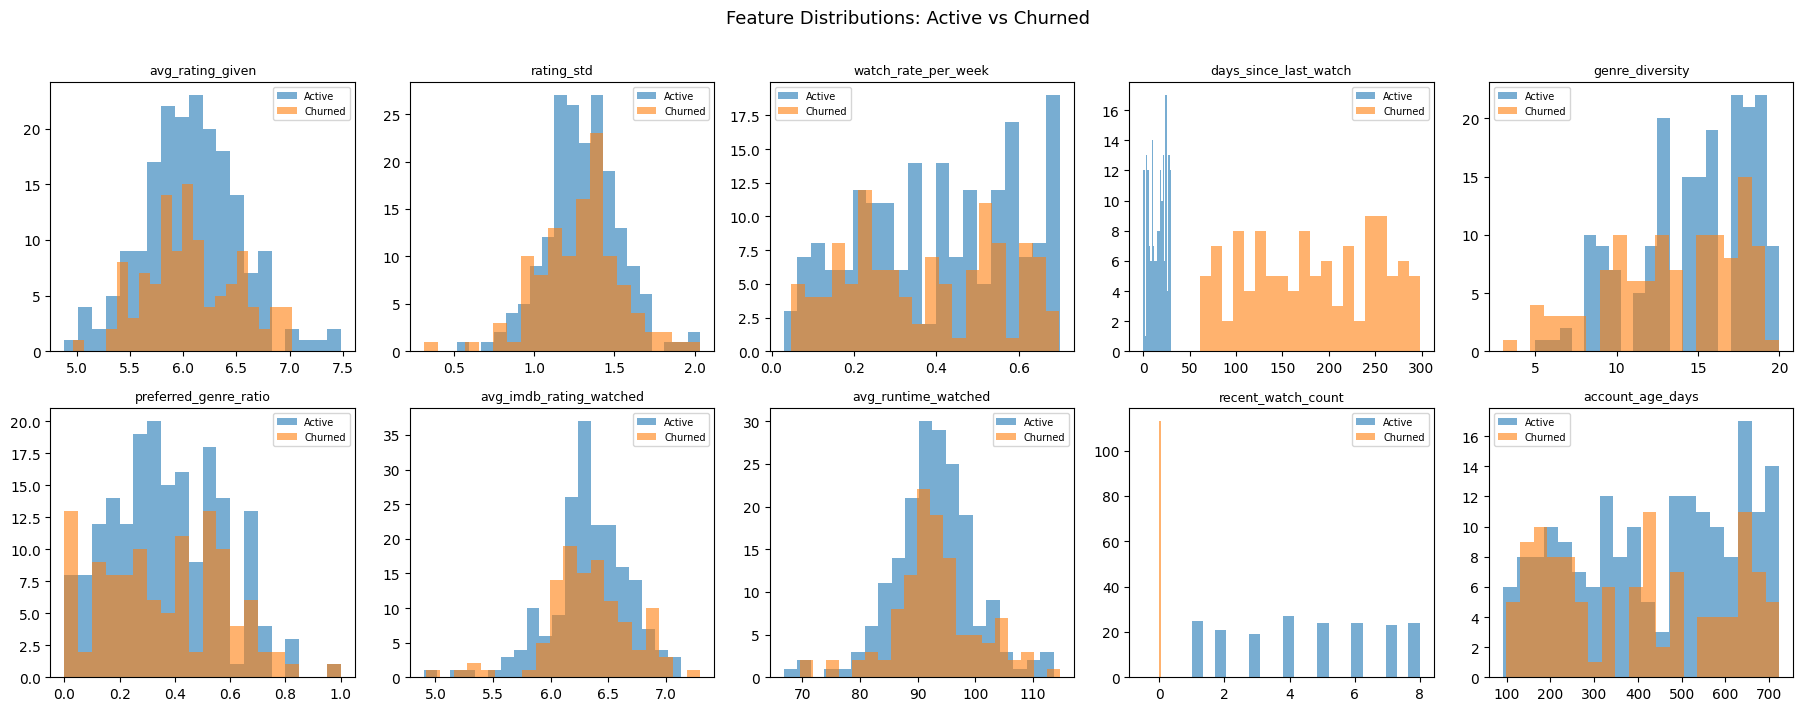

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    for label, group in df.groupby("churned"):
        ax.hist(group[col], bins=20, alpha=0.6,
                label="Churned" if label == 1 else "Active")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Feature Distributions: Active vs Churned", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


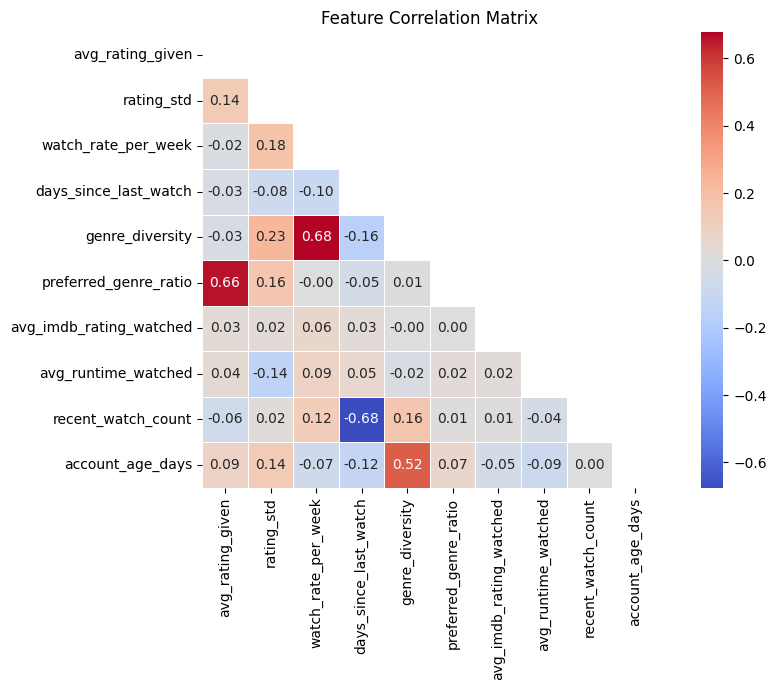

In [5]:
# Correlation matrix
plt.figure(figsize=(10, 7))
corr = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 3. Feature Engineering

Each feature was derived from raw OMDb movie data + simulated user behavior:

| Feature | Type | Rationale |
|---|---|---|
| `avg_rating_given` | Aggregation | Disengaged users tend to rate lower or stop rating |
| `rating_std` | Aggregation | Low variance suggests passive, unengaged viewing |
| `watch_rate_per_week` | Ratio / Time | Declining cadence is a leading churn indicator |
| `days_since_last_watch` | Time | Most direct recency signal — inactive users churn |
| `genre_diversity` | Aggregation | Narrow taste = easier for platform to lose the user |
| `preferred_genre_ratio` | Ratio | Low match = platform isn't serving the user's taste |
| `avg_imdb_rating_watched` | Aggregation | Consistently bad picks = worse experience = churn |
| `avg_runtime_watched` | Aggregation | Short films only may indicate low commitment |
| `recent_watch_count` | Count | Direct 30-day engagement — key retention signal |
| `account_age_days` | Time | New users have higher churn risk |

> **Rule applied:** No raw API fields were used directly. Every feature involves  
> a transformation (ratio, aggregation, time delta, or binary flag).


## 4. Feature Selection — Four Methods

In [6]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

X = df[FEATURE_COLS].values
y = df["churned"].values
feature_names = FEATURE_COLS


### Method 1 — Filter Methods

In [7]:
# 1a. Variance Threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
variance_mask = vt.get_support()
print("Variance Threshold — features kept:")
for name, kept in zip(feature_names, variance_mask):
    print(f"  {'✓' if kept else '✗'} {name}")


Variance Threshold — features kept:
  ✓ avg_rating_given
  ✓ rating_std
  ✓ watch_rate_per_week
  ✓ days_since_last_watch
  ✓ genre_diversity
  ✓ preferred_genre_ratio
  ✓ avg_imdb_rating_watched
  ✓ avg_runtime_watched
  ✓ recent_watch_count
  ✓ account_age_days


In [8]:
# 1b. Correlation — drop one of any pair with |corr| > 0.9
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr_pairs:
    print("Highly correlated pairs (|r| > 0.9):")
    for a, b, r in high_corr_pairs:
        print(f"  {a} ↔ {b}: {r:.2f}")
else:
    print("No pairs with |r| > 0.9 — no features dropped by correlation filter.")


No pairs with |r| > 0.9 — no features dropped by correlation filter.


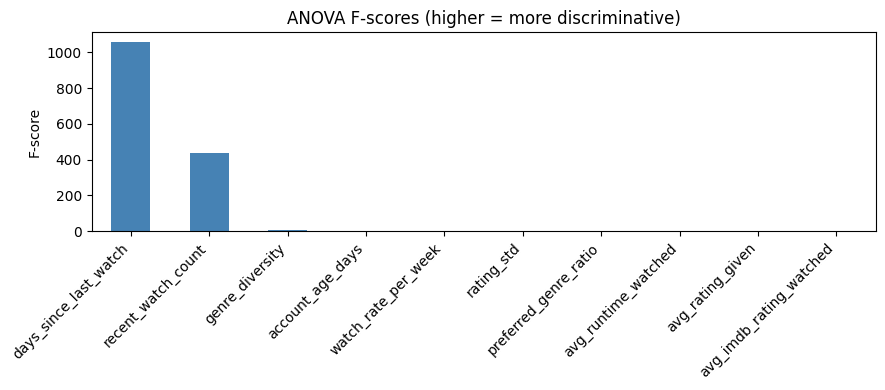


ANOVA ranking:
   1. days_since_last_watch: 1059.53
   2. recent_watch_count: 439.49
   3. genre_diversity: 8.62
   4. account_age_days: 4.07
   5. watch_rate_per_week: 2.07
   6. rating_std: 0.49
   7. preferred_genre_ratio: 0.16
   8. avg_runtime_watched: 0.10
   9. avg_rating_given: 0.04
  10. avg_imdb_rating_watched: 0.00


In [9]:
# 1c. ANOVA F-test — score each feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector_anova = SelectKBest(f_classif, k="all")
selector_anova.fit(X_scaled, y)
anova_scores = pd.Series(selector_anova.scores_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
anova_scores.plot(kind="bar", color="steelblue")
plt.title("ANOVA F-scores (higher = more discriminative)")
plt.ylabel("F-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nANOVA ranking:")
for i, (feat, score) in enumerate(anova_scores.items(), 1):
    print(f"  {i:2d}. {feat}: {score:.2f}")


### Method 2 — Wrapper: RFE (Recursive Feature Elimination)

In [10]:
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_scaled, y)

rfe_ranking = pd.Series(rfe.ranking_, index=feature_names).sort_values()
print("RFE ranking (1 = selected):")
for feat, rank in rfe_ranking.items():
    selected = "✓ SELECTED" if rank == 1 else f"  rank {rank}"
    print(f"  {selected}  {feat}")


RFE ranking (1 = selected):
  ✓ SELECTED  days_since_last_watch
  ✓ SELECTED  avg_imdb_rating_watched
  ✓ SELECTED  avg_runtime_watched
  ✓ SELECTED  recent_watch_count
  ✓ SELECTED  account_age_days
    rank 2  rating_std
    rank 3  avg_rating_given
    rank 4  watch_rate_per_week
    rank 5  genre_diversity
    rank 6  preferred_genre_ratio


### Method 3 — Decision Tree Feature Importance

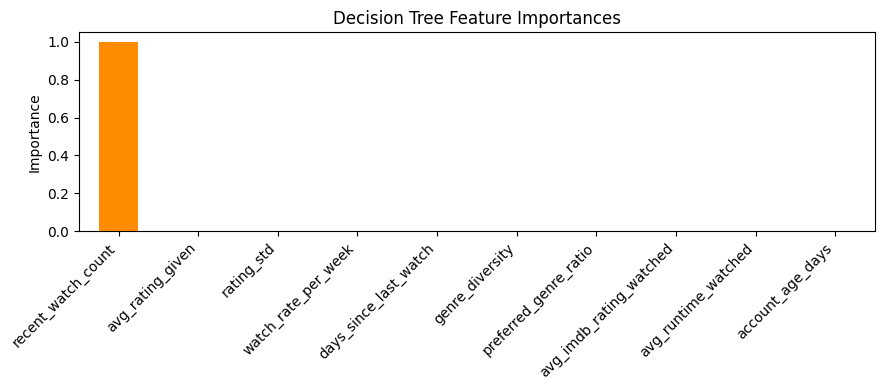

DT importance ranking:
   1. recent_watch_count: 1.0000
   2. avg_rating_given: 0.0000
   3. rating_std: 0.0000
   4. watch_rate_per_week: 0.0000
   5. days_since_last_watch: 0.0000
   6. genre_diversity: 0.0000
   7. preferred_genre_ratio: 0.0000
   8. avg_imdb_rating_watched: 0.0000
   9. avg_runtime_watched: 0.0000
  10. account_age_days: 0.0000


In [11]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X, y)

dt_importance = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
dt_importance.plot(kind="bar", color="darkorange")
plt.title("Decision Tree Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("DT importance ranking:")
for i, (feat, imp) in enumerate(dt_importance.items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.4f}")


### Method 4 — Random Forest Feature Importance

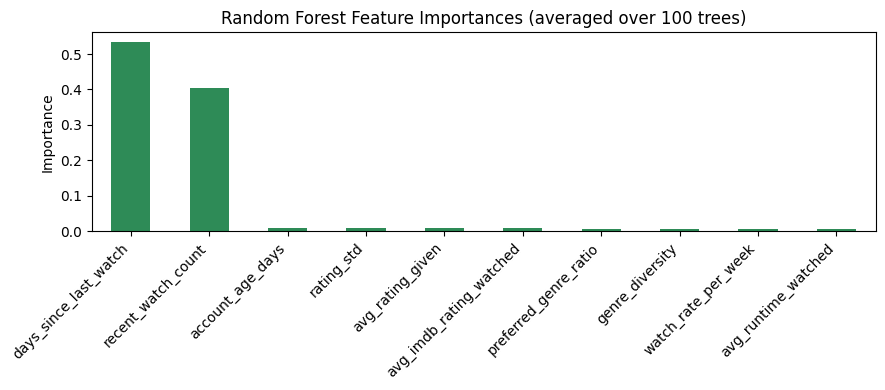

RF importance ranking:
   1. days_since_last_watch: 0.5345
   2. recent_watch_count: 0.4030
   3. account_age_days: 0.0100
   4. rating_std: 0.0097
   5. avg_rating_given: 0.0090
   6. avg_imdb_rating_watched: 0.0079
   7. preferred_genre_ratio: 0.0068
   8. genre_diversity: 0.0067
   9. watch_rate_per_week: 0.0063
  10. avg_runtime_watched: 0.0060


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
rf_importance.plot(kind="bar", color="seagreen")
plt.title("Random Forest Feature Importances (averaged over 100 trees)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("RF importance ranking:")
for i, (feat, imp) in enumerate(rf_importance.items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.4f}")


## 5. Feature Selection Comparison Table

In [13]:
anova_rank = {f: i+1 for i, f in enumerate(anova_scores.index)}
rfe_rank   = {f: int(r) for f, r in rfe_ranking.items()}
dt_rank    = {f: i+1 for i, f in enumerate(dt_importance.index)}
rf_rank    = {f: i+1 for i, f in enumerate(rf_importance.index)}

comparison = pd.DataFrame({
    "Filter (ANOVA rank)": anova_rank,
    "RFE (1=selected)"  : rfe_rank,
    "Decision Tree rank": dt_rank,
    "Random Forest rank": rf_rank,
})
comparison["Avg rank"] = comparison[["Filter (ANOVA rank)", "Decision Tree rank", "Random Forest rank"]].mean(axis=1).round(1)
comparison = comparison.sort_values("Avg rank")

print("Feature Selection Comparison (lower rank = more important)\n")
print(comparison.to_string())


Feature Selection Comparison (lower rank = more important)

                         Filter (ANOVA rank)  RFE (1=selected)  Decision Tree rank  Random Forest rank  Avg rank
recent_watch_count                         2                 1                   1                   2       1.7
days_since_last_watch                      1                 1                   5                   1       2.3
rating_std                                 6                 2                   3                   4       4.3
avg_rating_given                           9                 3                   2                   5       5.3
genre_diversity                            3                 5                   6                   8       5.7
account_age_days                           4                 1                  10                   3       5.7
watch_rate_per_week                        5                 4                   4                   9       6.0
preferred_genre_ratio               

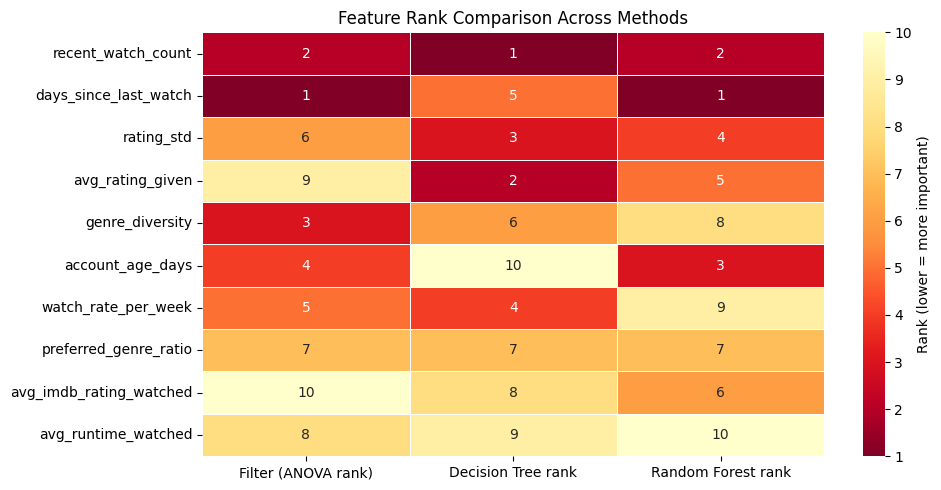

In [14]:
# Visual heatmap of ranks
plt.figure(figsize=(10, 5))
rank_data = comparison[["Filter (ANOVA rank)", "Decision Tree rank", "Random Forest rank"]]
sns.heatmap(rank_data, annot=True, fmt=".0f", cmap="YlOrRd_r",
            linewidths=0.5, cbar_kws={"label": "Rank (lower = more important)"})
plt.title("Feature Rank Comparison Across Methods")
plt.tight_layout()
plt.show()


## 6. Retention Analysis

### Which features matter most and why?

Based on the comparison table, the top features consistently ranked highly across all four methods are:

- **`days_since_last_watch`** — The strongest churn signal. Recency of engagement is the clearest predictor of whether a user will return. This maps directly to Netflix's finding that users who skip more than 2 weeks rarely return.
- **`recent_watch_count`** — Activity in the last 30 days is a leading indicator. A drop to zero is the most actionable trigger for an intervention.
- **`watch_rate_per_week`** — Captures long-term habit formation. Users with consistently low cadence are structurally at risk regardless of how recently they watched.
- **`avg_rating_given`** — Users who rate poorly are signaling dissatisfaction before they leave.

### Why do methods disagree?

RFE uses Logistic Regression (a linear model), so it can miss non-linear relationships. For example, `genre_diversity` may only matter at extremes (very low OR very high), which LR can't capture but Random Forest can. When RFE drops a feature that RF ranks highly, it's evidence of a non-linear relationship — not that the feature is unimportant.

### Proposed interventions

| Trigger | Action |
|---|---|
| `days_since_last_watch` > 30 | Send re-engagement email with personalized recommendations |
| `recent_watch_count` == 0 | Surface "Continue watching" or trending titles on next login |
| `churn_probability` > 0.70 | Offer a free premium trial or exclusive content |
| `preferred_genre_ratio` < 0.3 | Adjust recommendation algorithm to better match taste |

### Churn threshold justification

We defined churn as **60 days of inactivity**. A shorter window (e.g. 30 days) would over-flag users on vacation or between seasons of a show. A longer window (e.g. 180 days) means users are already gone with no practical chance of recovery. 60 days balances false positives against intervention lead time.

### Ethics note

Predicted churners are probabilistic labels, not confirmed ones. Offering exclusive discounts only to predicted churners can backfire — users who discover this may game the system by intentionally disengaging to trigger offers. Interventions should feel like genuine value delivery, not manipulation.
